# Folded Dalitz Plot / Square Dalitz Plot: $B^\pm \to \pi^\pm\pi^+\pi^-$

$B^+ \to \pi^+\pi^+\pi^-$ has two identical same-sign pions, so the physics is
symmetric under exchanging them. This notebook demonstrates the `folded=True`
support added to efficiency/background models and plotting:

- `SquareDalitzHistogramEfficiency`/`SquareDalitzHistogramBackground` (`(m', theta')`)
- `HistogramEfficiency`/`HistogramBackground` (plain `s12`/`s13`)
- `plot_dalitz`/`plot_square_dalitz`

folded onto the physically distinct half, for both a CP toy fit
(`CPFitSession`, $B^+$ vs $B^-$) built with these folded models throughout.

Folding is a **statistics** tool for building efficiency/background maps from
limited samples, not a correctness requirement: `DecayChannel` already
detects the two identical $\pi^+$ from their PDG IDs and automatically
symmetrizes the `rho0` resonance amplitude under their exchange, so the
unbinned fit itself is already correct on the full (unfolded) Dalitz plane.
`DecayModel`'s normalization/generation grid is therefore intentionally left
on the full domain (see `docs/backgrounds_and_vetoes.md`); only the
efficiency/background *inputs* and the diagnostic plots are folded here.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from dalitzplotfitter import (
    CPBackgroundSpec, CPFitSession, CPRealImag, DecayChannel, DecayModel,
    NonResonant, Parameter, Resonance, SquareDalitzHistogramEfficiency,
    enable_x64, generate_cp_toy, plot_dalitz, plot_square_dalitz,
)
from dalitzplotfitter.background import HistogramBackground
enable_x64()


## Amplitude model: $\rho(770)^0 + \mathrm{NR}$, with direct CP violation

`DecayChannel("B+", ("pi-", "pi+", "pi+"))` labels particles `0 = pi-`,
`1 = pi+`, `2 = pi+`: the identical pair is `(1, 2)`. Declaring `rho0` on
`pair=(0, 1)` is enough -- `DecayModel` automatically adds the symmetric
`pair=(0, 2)` term for the identical `pi+`. `CPRealImag(x, y, dx, dy)` gives
each component an independent $B^+$/$B^-$ coefficient split
(`.for_charge(+1)`/`.for_charge(-1)`), the same convention used throughout
the CP notebooks. As in those notebooks, `rho0`'s CP-averaged `(x, y)` is
fixed as the overall phase/scale reference (only relative phases between
components are physical) and `NR`'s `(dx, dy)` is fixed to zero, so the fit
attributes the CP asymmetry to `rho0.dx`/`rho0.dy`.


In [9]:
truth_spec = {
    "rho0": (0.75, 0.10, +0.08, -0.05),
    "NR": (-0.35, 0.20, 0.0, 0.0),
}
truth = {}
shared = {}
for name, (x, y, dx, dy) in truth_spec.items():
    pars = (
        Parameter.coefficient(f"{name}.x", x, owner=name, fixed=(name == "rho0"), step=0.01),
        Parameter.coefficient(f"{name}.y", y, owner=name, fixed=(name == "rho0"), step=0.01),
        Parameter.coefficient(f"{name}.dx", dx, owner=name, fixed=(name == "NR"), step=0.01),
        Parameter.coefficient(f"{name}.dy", dy, owner=name, fixed=(name == "NR"), step=0.01),
    )
    shared[name] = CPRealImag(*pars)
    truth.update({p.name: p.value for p in pars})

def components(charge):
    rho = Resonance("rho0", (0, 1), shared["rho0"].for_charge(charge))
    nr = NonResonant(shared["NR"].for_charge(charge))
    return [rho, nr]

plus_model = DecayModel(
    DecayChannel("B+", ("pi-", "pi+", "pi+")),
    components(+1),
    normalization_method="square-dalitz",
    normalization_resolution=32,
)
minus_model = DecayModel(
    DecayChannel("B-", ("pi+", "pi-", "pi-")),
    components(-1),
    normalization_method="square-dalitz",
    normalization_resolution=32,
)
print(plus_model.channel.final_state_ids, "-> identical pair (1, 2)")


(-211, 211, 211) -> identical pair (1, 2)


## Folded efficiency and background

`SquareDalitzHistogramEfficiency(..., pair=(1, 2), folded=True)` folds
`theta'` onto `[0, 0.5]` -- `pair` is the identical pair itself, matching the
plot below. The combinatorial background is instead built directly in plain
`(s12, s13)` coordinates via `HistogramBackground(..., folded=True)`, folded
by `min`/`max`, to exercise both folded entry points in one fit.


In [10]:
mp_edges = np.linspace(0.0, 1.0, 11)
tp_edges = np.linspace(0.0, 0.5, 6)
MP, TP = np.meshgrid(0.5 * (mp_edges[:-1] + mp_edges[1:]),
                      0.5 * (tp_edges[:-1] + tp_edges[1:]), indexing="ij")
eff_values = 0.55 + 0.30 * MP + 0.10 * np.cos(np.pi * TP)

efficiency = SquareDalitzHistogramEfficiency(
    mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=eff_values,
    mother_mass=plus_model.channel.parent_mass,
    masses=plus_model.channel.daughter_masses,
    pair=(1, 2), folded=True,
)

s_edges = np.linspace(0.0, 25.0, 11)
SA, SB = np.meshgrid(0.5 * (s_edges[:-1] + s_edges[1:]),
                      0.5 * (s_edges[:-1] + s_edges[1:]), indexing="ij")
bkg_values = np.abs(1.0 + 0.06 * SA - 0.03 * SB)

background = HistogramBackground(
    x_edges=s_edges, y_edges=s_edges, values=bkg_values,
    x_variable="s12", y_variable="s13", folded=True,
)


## Generate a CP toy and visualize the fold

`plot_dalitz`/`plot_square_dalitz(folded=True)` fold the *observed* toy the
same way, purely for visualization -- the toy itself is generated over the
full physical Dalitz plane (folding the model would double-count phase
space).


B+ / B-: 11276 8724


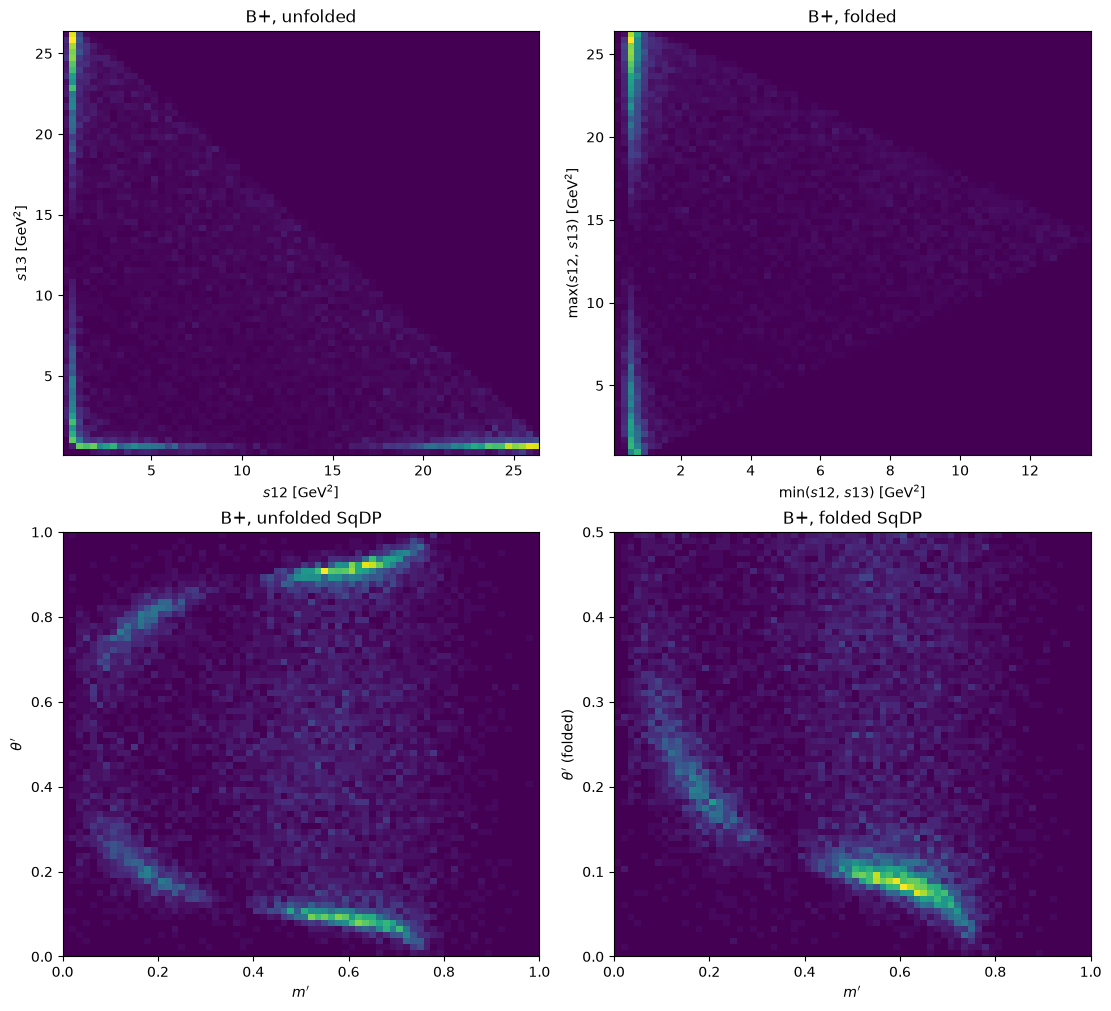

In [11]:
signal_fraction = 0.82
background_spec = CPBackgroundSpec("comb", background)
plus_data, minus_data = generate_cp_toy(
    plus_model, minus_model, 20_000, parameters=truth,
    plus_efficiency=efficiency, minus_efficiency=efficiency,
    signal_fraction=signal_fraction, backgrounds=(background_spec,), seed=2306,
)
print("B+ / B-:", plus_data.size, minus_data.size)

fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)
plot_dalitz(plus_data, x="s12", y="s13", ax=axes[0, 0], title="B+, unfolded", colorbar=False)
plot_dalitz(plus_data, x="s12", y="s13", ax=axes[0, 1], title="B+, folded", colorbar=False, folded=True)
plot_square_dalitz(
    plus_data, mother_mass=plus_model.channel.parent_mass,
    masses=plus_model.channel.daughter_masses, pair=(1, 2),
    ax=axes[1, 0], title="B+, unfolded SqDP", colorbar=False,
)
plot_square_dalitz(
    plus_data, mother_mass=plus_model.channel.parent_mass,
    masses=plus_model.channel.daughter_masses, pair=(1, 2),
    ax=axes[1, 1], title="B+, folded SqDP", colorbar=False, folded=True,
)
plt.show()


## CP fit with the folded efficiency/background

`CPFitSession` composes exactly like it would with any other
efficiency/background model -- folding is invisible to the fit machinery,
only the fold-aware classes evaluate the map on the correct half.


In [12]:
session = (
    CPFitSession(
        plus_model, minus_model, plus_data, minus_data,
        backgrounds=(background_spec,),
        signal_fraction=Parameter("signal_fraction", signal_fraction, bounds=(0.05, 0.99)),
    )
    .with_efficiency(efficiency)
)

rng = np.random.default_rng(2306)
start = {
    p.name: truth.get(p.name, signal_fraction) + rng.normal(0, 0.05)
    for p in session.parameters if not p.fixed
}
result = session.fit(start, simplex=True, ncall=60_000)
session.report(result)


valid=True  NLL=114986.992956
parameter                           value            error
rho0.x                               0.75                0
rho0.y                                0.1                0
rho0.dx                         0.0838596       0.00542122
rho0.dy                         -0.060611        0.0242109
NR.x                            -0.384501       0.00751128
NR.y                             0.184019        0.0174534
NR.dx                                   0                0
NR.dy                                   0                0
signal_fraction                  0.800616       0.00707483
predicted charge fractions: B+=0.558828  B-=0.441172
B+ fit fractions
Fit fractions (physical)
component                    fraction [%]
rho0                               79.336
NR                                 20.686
sum                               100.023

B- fit fractions
Fit fractions (physical)
component                    fraction [%]
rho0                            

{'valid': True,
 'nll': 114986.99295569252,
 'edm': 1.2678900688178957e-10,
 'nfcn': 670,
 'values': {'rho0.x': 0.75,
  'rho0.y': 0.1,
  'rho0.dx': 0.08385959571946214,
  'rho0.dy': -0.06061104126301267,
  'NR.x': -0.38450108561926644,
  'NR.y': 0.1840186827498245,
  'NR.dx': 0.0,
  'NR.dy': 0.0,
  'signal_fraction': 0.8006163182634177},
 'errors': {'rho0.x': 0.0,
  'rho0.y': 0.0,
  'rho0.dx': 0.00542122474018673,
  'rho0.dy': 0.024210911885120333,
  'NR.x': 0.007511284651232368,
  'NR.y': 0.01745335195989272,
  'NR.dx': 0.0,
  'NR.dy': 0.0,
  'signal_fraction': 0.007074830065097626},
 'charge_probabilities': {'plus': 0.5588281990625255,
  'minus': 0.4411718009374745},
 'fit_fractions': {'plus': {'rho0': 0.7933627034363817,
   'NR': 0.2068627713067845},
  'minus': {'rho0': 0.7211560527024828, 'NR': 0.2790757025110731}},
 'correlation': {'rho0.dx': {'rho0.dx': 0.9999999999999999,
   'rho0.dy': -0.7108107210101191,
   'NR.x': -0.2622733895041578,
   'NR.y': -0.1052129182491514,
   'signa

`plot_projection` always renders one panel per charge (`axes` takes a
``[B+ axis, B- axis]`` pair, never a single axis, so it is never passed
explicitly below). Without folding, `s12` and `s13` are shown separately.
`folded=True` with `partner_variable` instead projects onto
`s_low = min(s12, s13)`/`s_high = max(s12, s13)` (`fold_side="low"`/`"high"`)
event by event -- the same `min`/`max` fold `plot_dalitz`/
`plot_square_dalitz`/the folded efficiency and background maps above use, now
applied to a 1D projection.


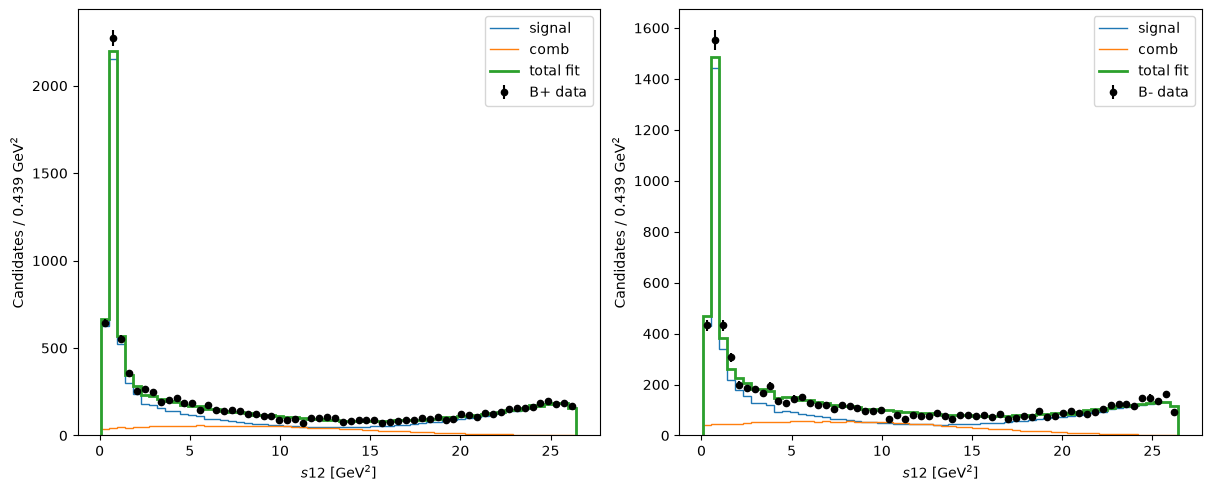

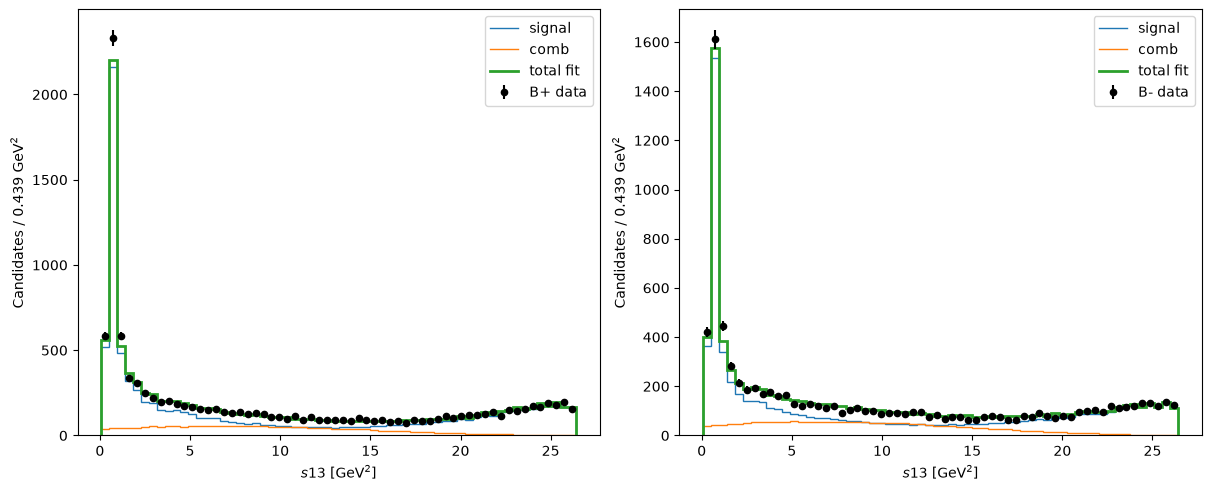

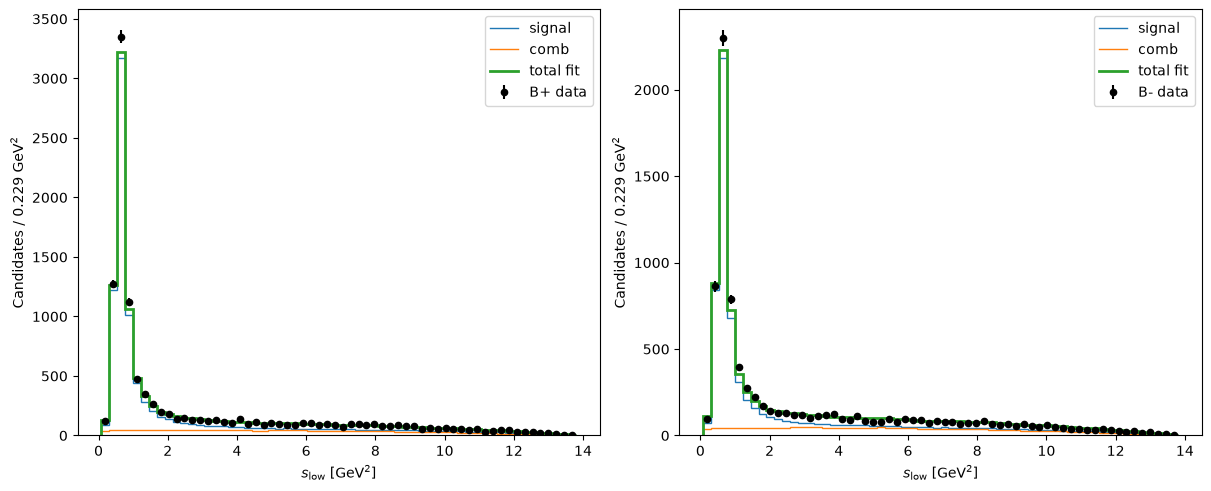

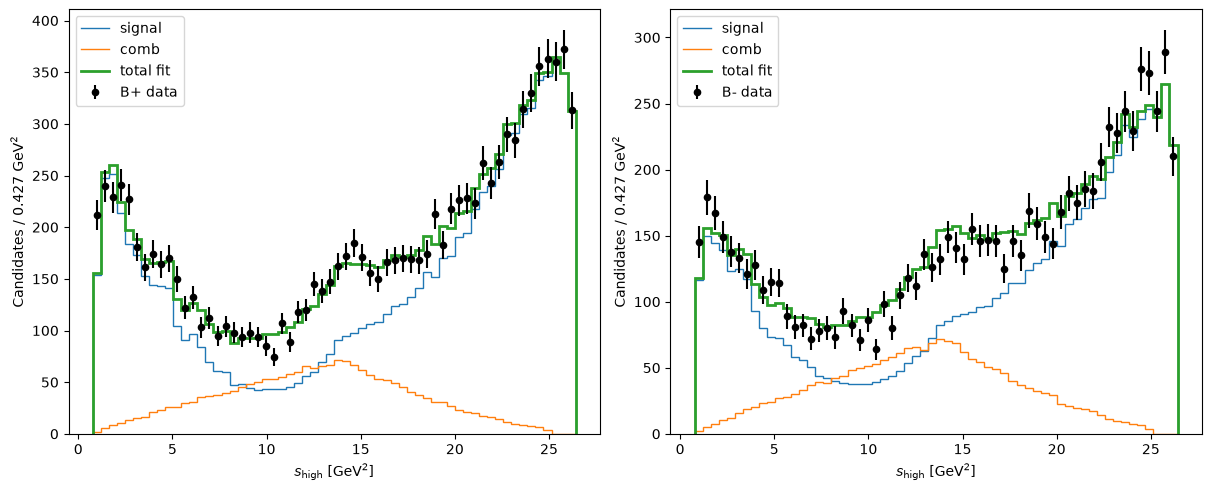

In [13]:
session.plot_projection(result, "s12")
plt.show()
session.plot_projection(result, "s13")
plt.show()

session.plot_projection(result, "s12", folded=True, partner_variable="s13", fold_side="low")
plt.show()
session.plot_projection(result, "s12", folded=True, partner_variable="s13", fold_side="high")
plt.show()


## Folded view of the fit result

Generating a toy from the fitted parameters and folding it the same way as
the data gives a compact, statistics-doubled comparison of the fit quality on
the physically distinct half of the plane.


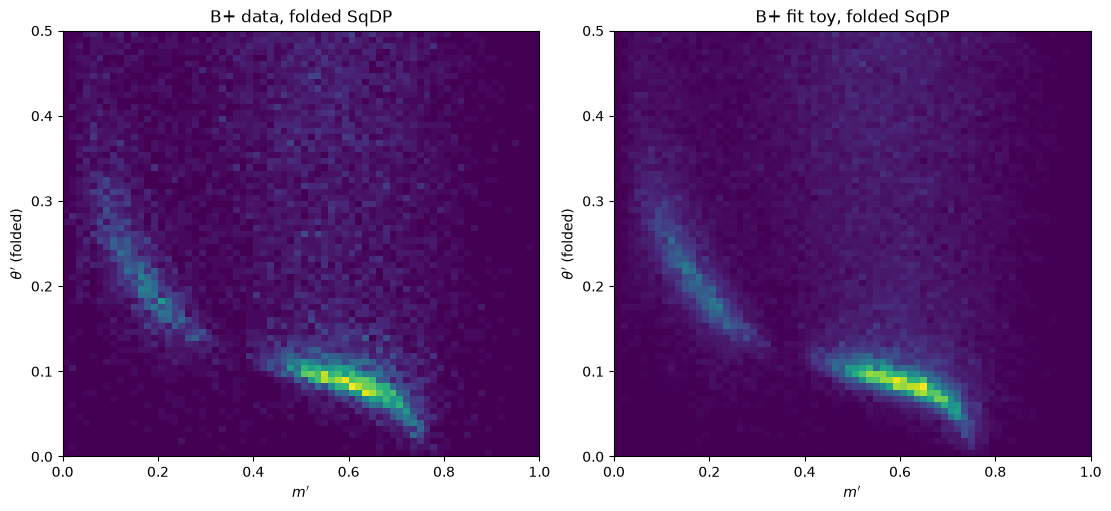

In [14]:
fitted = session.result_values(result)
fit_plus, fit_minus = generate_cp_toy(
    plus_model, minus_model, 60_000, parameters=fitted,
    plus_efficiency=efficiency, minus_efficiency=efficiency,
    signal_fraction=fitted["signal_fraction"], backgrounds=(background_spec,), seed=99,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
plot_square_dalitz(
    plus_data, mother_mass=plus_model.channel.parent_mass,
    masses=plus_model.channel.daughter_masses, pair=(1, 2),
    ax=axes[0], title="B+ data, folded SqDP", colorbar=False, folded=True,
)
plot_square_dalitz(
    fit_plus, mother_mass=plus_model.channel.parent_mass,
    masses=plus_model.channel.daughter_masses, pair=(1, 2),
    ax=axes[1], title="B+ fit toy, folded SqDP", colorbar=False, folded=True,
)
plt.show()
